Output()

Output()

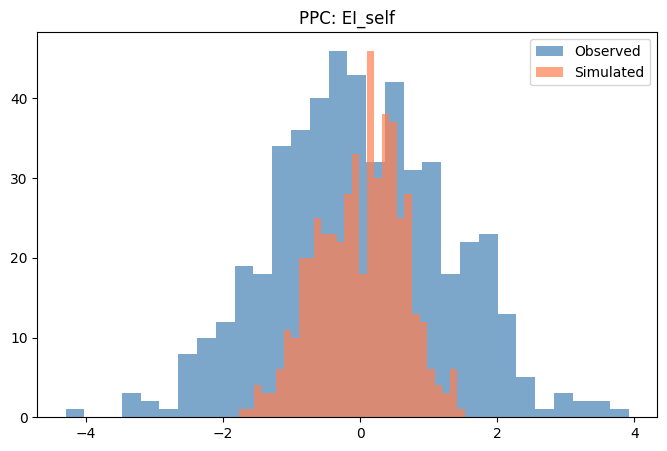

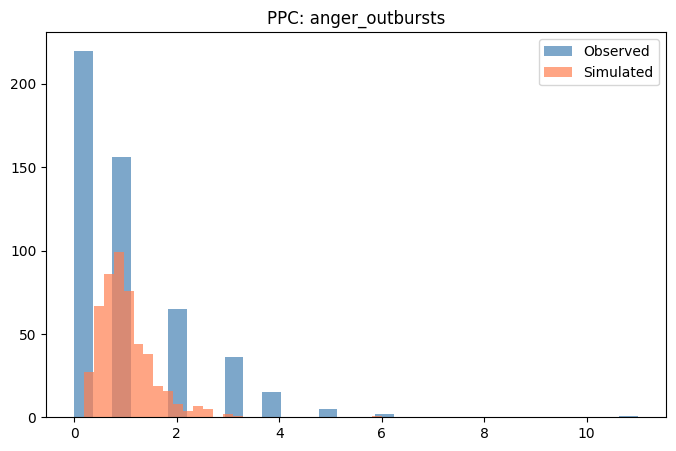

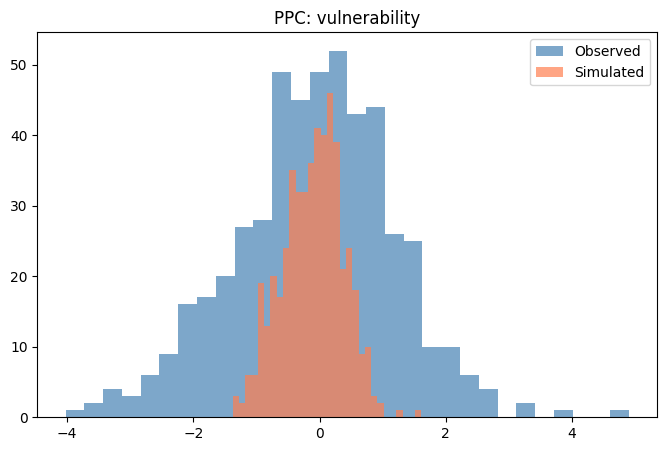

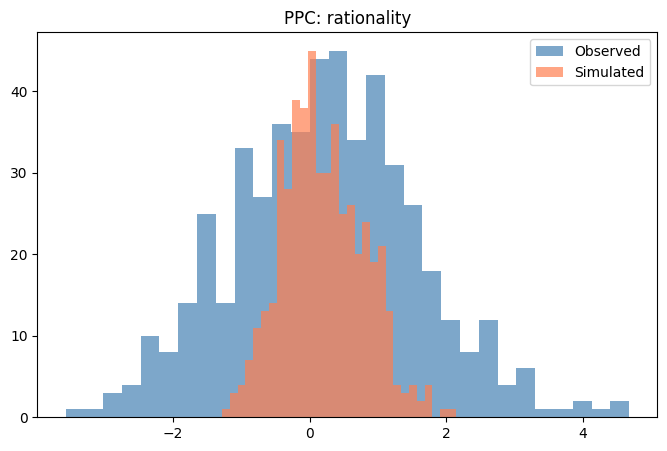

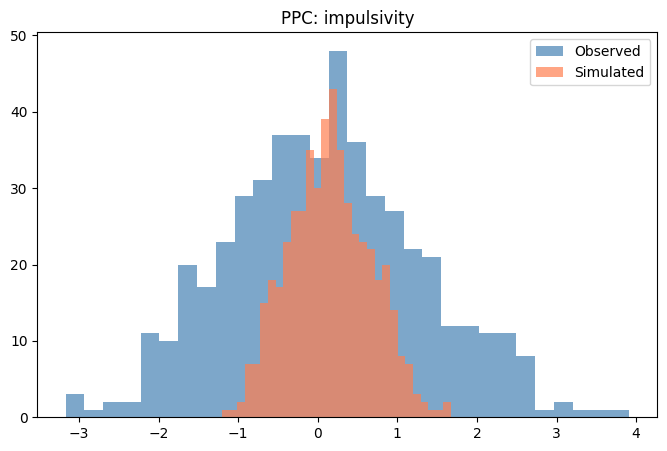

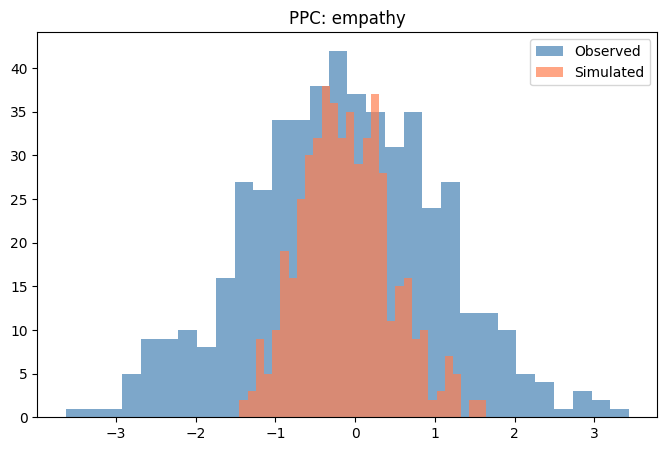

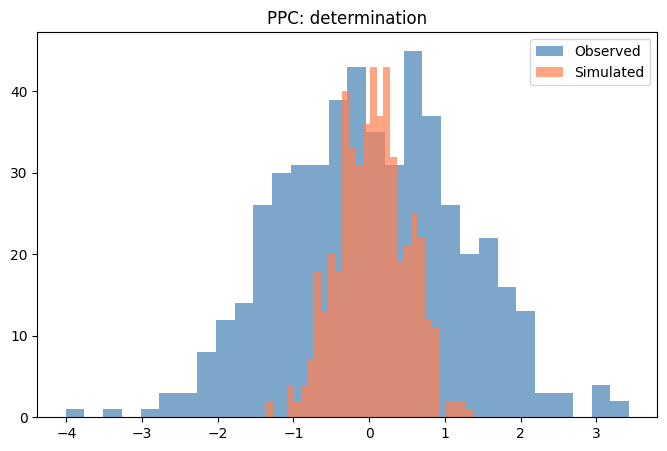

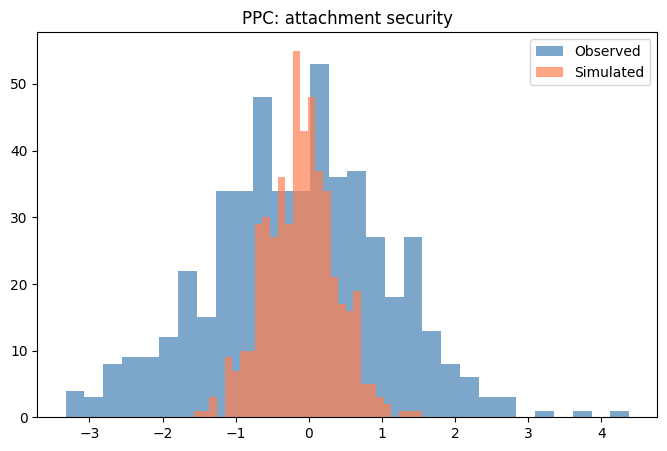

-----------------------------------------------------------------
P1 - Does Cholesky rewrite fire?
-----------------------------------------------------------------

[Model A] Using chol= — PyTensor should use SolveTriangular

--- Graph for theta_zodiac logp (chol= version) ---
Sum{axes=None} [id A] '__logp'
 └─ Alloc [id B] 'theta_zodiac_logprob'
    ├─ Check{posdef covariance} [id C]
    │  ├─ Sub [id D]
    │  │  ├─ Sub [id E]
    │  │  │  ├─ ExpandDims{axis=0} [id F]
    │  │  │  │  └─ Mul [id G]
    │  │  │  │     ├─ Mul [id H]
    │  │  │  │     │  ├─ -0.5 [id I]
    │  │  │  │     │  └─ Cast{float64} [id J]
    │  │  │  │     │     └─ Subtensor{i} [id K]
    │  │  │  │     │        ├─ Shape [id L]
    │  │  │  │     │        │  └─ theta_zodiac [id M]
    │  │  │  │     │        └─ -1 [id N]
    │  │  │  │     └─ 1.8378770664093453 [id O]
    │  │  │  └─ Mul [id P]
    │  │  │     ├─ ExpandDims{axis=0} [id Q]
    │  │  │     │  └─ 0.5 [id R]
    │  │  │     └─ Sum{axis=1} [id S]


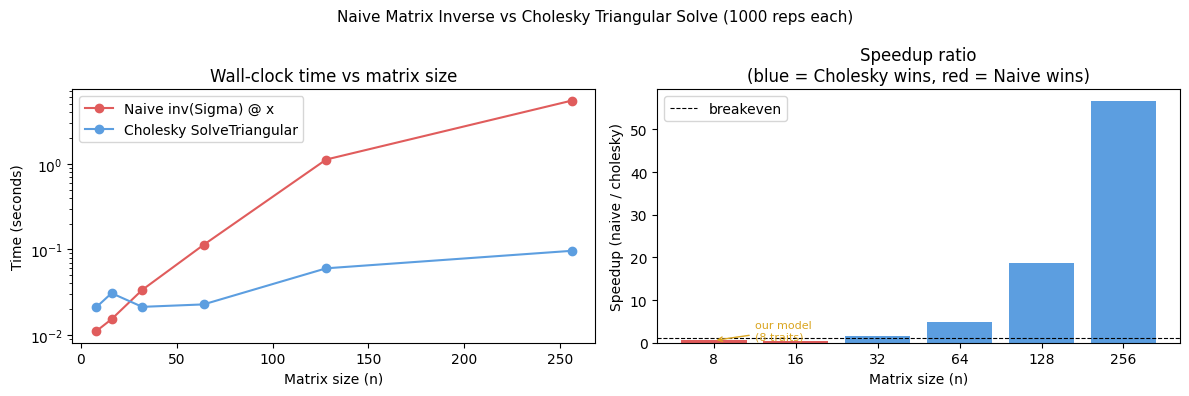


  Key insight: at 8x8 (our model) the overhead is negligible.
  At 128x128+ Cholesky wins decisively — and numerical stability
  matters at ALL sizes during MCMC.


-----------------------------------------------------------------
PART 2: NEGATION FOLDING — a missing rewrite
-----------------------------------------------------------------

In our model:
  pm.Normal("abandonment_fear", mu=-theta_ind[:, 7], ...)

The Normal logp computes:  -0.5 * ((obs - mu) / sigma)^2
Substituting mu = -theta:  -0.5 * ((obs + theta) / sigma)^2

But PyTensor builds the graph as:
  Mul([-1.], theta_ind[:,7])   <- explicit negation node
  Sub(obs, Mul(...))           <- subtraction
  Pow(..., 2)                  <- squaring

The negation is REDUNDANT because (-x)^2 = x^2.
A rewrite could fold it away: Pow(Mul(-1, x), 2) -> Pow(x, 2)

--- Current graph (with redundant negation) ---
Mul [id A]
 ├─ ExpandDims{axis=0} [id B]
 │  └─ -0.5 [id C]
 └─ Pow [id D]
    ├─ True_div [id E]
    │  ├─ Sub [id F]
    │ 

In [ ]:
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt

rng = np.random.default_rng(69)

N = 500
N_ZODIAC = 12
N_TRAITS = 8

zodiac_idx = rng.integers(0, N_ZODIAC, size=N)

theta_zodiac_true = rng.normal(0, 0.4, size=(N_ZODIAC, N_TRAITS))
theta_ind_true = theta_zodiac_true[zodiac_idx] + rng.normal(0, 0.6, size=(N, N_TRAITS))

EI_self = theta_ind_true[:, 0] + rng.normal(0, 1, N)
EI_regulation = theta_ind_true[:, 0] + rng.normal(0, 1, N)
anger_outbursts = rng.poisson(lam=np.exp(theta_ind_true[:, 1]))
anger_intensity = theta_ind_true[:, 1] + rng.normal(0, 1, N)
vuln_openness = theta_ind_true[:, 2] + rng.normal(0, 1, N)
vuln_disclosure = theta_ind_true[:, 2] + rng.normal(0, 1, N)
logic_score = theta_ind_true[:, 3] + rng.normal(0, 1, N)
bias_resistance = theta_ind_true[:, 3] + rng.normal(0, 1, N)
risk_score = theta_ind_true[:, 4] + rng.normal(0, 1, N)
delay_discounting = theta_ind_true[:, 4] + rng.normal(0, 1, N)
empathy_affective = theta_ind_true[:, 5] + rng.normal(0, 1, N)
empathy_cognitive = theta_ind_true[:, 5] + rng.normal(0, 1, N)
grit_score = theta_ind_true[:, 6] + rng.normal(0, 1, N)
persistence_score = theta_ind_true[:, 6] + rng.normal(0, 1, N)
closeness_comfort = theta_ind_true[:, 7] + rng.normal(0, 1, N)
abandonment_fear = -theta_ind_true[:, 7] + rng.normal(0, 1, N)

with pm.Model() as model:
    chol, _, _ = pm.LKJCholeskyCov("trait_cov", n=N_TRAITS, eta=3, sd_dist=pm.HalfNormal.dist(0.5))
    theta_zodiac = pm.MvNormal("theta_zodiac", mu=np.zeros(N_TRAITS), chol=chol, shape=(N_ZODIAC, N_TRAITS))
    sigma_person = pm.HalfNormal("sigma_person", 0.6)
    theta_ind = pm.Normal("theta_ind", mu=theta_zodiac[zodiac_idx], sigma=sigma_person, shape=(N, N_TRAITS))

    pm.Normal("EI_self", mu=theta_ind[:, 0], sigma=1, observed=EI_self)
    pm.Normal("EI_regulation", mu=theta_ind[:, 0], sigma=1, observed=EI_regulation)
    pm.Poisson("anger_outbursts", mu=pm.math.exp(theta_ind[:, 1]), observed=anger_outbursts)
    pm.Normal("anger_intensity", mu=theta_ind[:, 1], sigma=1, observed=anger_intensity)
    pm.Normal("vuln_openness", mu=theta_ind[:, 2], sigma=1, observed=vuln_openness)
    pm.Normal("vuln_disclosure", mu=theta_ind[:, 2], sigma=1, observed=vuln_disclosure)
    pm.Normal("logic_score", mu=theta_ind[:, 3], sigma=1, observed=logic_score)
    pm.Normal("bias_resistance", mu=theta_ind[:, 3], sigma=1, observed=bias_resistance)
    pm.Normal("risk_score", mu=theta_ind[:, 4], sigma=1, observed=risk_score)
    pm.Normal("delay_discounting", mu=theta_ind[:, 4], sigma=1, observed=delay_discounting)
    pm.Normal("empathy_affective", mu=theta_ind[:, 5], sigma=1, observed=empathy_affective)
    pm.Normal("empathy_cognitive", mu=theta_ind[:, 5], sigma=1, observed=empathy_cognitive)
    pm.Normal("grit_score", mu=theta_ind[:, 6], sigma=1, observed=grit_score)
    pm.Normal("persistence_score", mu=theta_ind[:, 6], sigma=1, observed=persistence_score)
    pm.Normal("closeness_comfort", mu=theta_ind[:, 7], sigma=1, observed=closeness_comfort)
    pm.Normal("abandonment_fear", mu=-theta_ind[:, 7], sigma=1, observed=abandonment_fear)

    trace = pm.sample(draws=1000, tune=1000, chains=4, target_accept=0.9, init="adapt_diag", random_seed=69, return_inferencedata=False)

with model:
    ppc = pm.sample_posterior_predictive(trace, random_seed=69, return_inferencedata=False)

def ppc_plot(obs, sim, title):
    plt.figure(figsize=(8, 5))
    plt.hist(obs, bins=30, alpha=0.7, label="Observed", color='steelblue')
    plt.hist(sim.mean(axis=(0, 1)), bins=30, alpha=0.7, label="Simulated", color='coral')
    plt.legend()
    plt.title(title)
    plt.show()

ppc_plot(EI_self, ppc["EI_self"], "PPC: EI_self")
ppc_plot(anger_outbursts, ppc["anger_outbursts"], "PPC: anger_outbursts")
ppc_plot(vuln_openness, ppc["vuln_openness"], "PPC: vulnerability")
ppc_plot(logic_score, ppc["logic_score"], "PPC: rationality")
ppc_plot(risk_score, ppc["risk_score"], "PPC: impulsivity")
ppc_plot(empathy_affective, ppc["empathy_affective"], "PPC: empathy")
ppc_plot(grit_score, ppc["grit_score"], "PPC: determination")
ppc_plot(closeness_comfort, ppc["closeness_comfort"], "PPC: attachment security")


import pytensor
import pytensor.tensor as pt
from scipy.linalg import solve_triangular
import time
import warnings
warnings.filterwarnings("ignore")

print("-" * 65)
print("P1 - Does Cholesky rewrite fire?")
print("-" * 65)

# ── MODEL A: Cholesky-aware (chol=)
print("\n[Model A] Using chol= — PyTensor should use SolveTriangular")

with pm.Model() as model_chol:
    chol, _, _ = pm.LKJCholeskyCov(
        "trait_cov", n=N_TRAITS, eta=3, sd_dist=pm.HalfNormal.dist(0.5)
    )
    theta_zodiac = pm.MvNormal(
        "theta_zodiac", mu=np.zeros(N_TRAITS), chol=chol, shape=(N_ZODIAC, N_TRAITS)
    )
    sigma_person = pm.HalfNormal("sigma_person", 0.6)
    theta_ind = pm.Normal(
        "theta_ind", mu=theta_zodiac[zodiac_idx], sigma=sigma_person, shape=(N, N_TRAITS)
    )
    pm.Normal("EI_self",           mu=theta_ind[:, 0], sigma=1, observed=EI_self)
    pm.Normal("EI_regulation",     mu=theta_ind[:, 0], sigma=1, observed=EI_regulation)
    pm.Poisson("anger_outbursts",  mu=pm.math.exp(theta_ind[:, 1]), observed=anger_outbursts)
    pm.Normal("anger_intensity",   mu=theta_ind[:, 1], sigma=1, observed=anger_intensity)
    pm.Normal("vuln_openness",     mu=theta_ind[:, 2], sigma=1, observed=vuln_openness)
    pm.Normal("vuln_disclosure",   mu=theta_ind[:, 2], sigma=1, observed=vuln_disclosure)
    pm.Normal("logic_score",       mu=theta_ind[:, 3], sigma=1, observed=logic_score)
    pm.Normal("bias_resistance",   mu=theta_ind[:, 3], sigma=1, observed=bias_resistance)
    pm.Normal("risk_score",        mu=theta_ind[:, 4], sigma=1, observed=risk_score)
    pm.Normal("delay_discounting", mu=theta_ind[:, 4], sigma=1, observed=delay_discounting)
    pm.Normal("empathy_affective", mu=theta_ind[:, 5], sigma=1, observed=empathy_affective)
    pm.Normal("empathy_cognitive", mu=theta_ind[:, 5], sigma=1, observed=empathy_cognitive)
    pm.Normal("grit_score",        mu=theta_ind[:, 6], sigma=1, observed=grit_score)
    pm.Normal("persistence_score", mu=theta_ind[:, 6], sigma=1, observed=persistence_score)
    pm.Normal("closeness_comfort", mu=theta_ind[:, 7], sigma=1, observed=closeness_comfort)
    pm.Normal("abandonment_fear",  mu=-theta_ind[:, 7], sigma=1, observed=abandonment_fear)

print("\n--- Graph for theta_zodiac logp (chol= version) ---")
pytensor.dprint(model_chol.logp(vars=[model_chol["theta_zodiac"]]))


# MODEL B: Naive covariance (cov=)
print("\n\n[Model B] Using cov= — PyTensor will NOT use the Cholesky path")

with pm.Model() as model_cov:
    chol_raw, _, _ = pm.LKJCholeskyCov(
        "trait_cov", n=N_TRAITS, eta=3, sd_dist=pm.HalfNormal.dist(0.5)
    )
    # Reconstruct full covariance matrix — PyTensor loses track of the Cholesky factor
    Sigma = chol_raw @ chol_raw.T
    theta_zodiac_cov = pm.MvNormal(
        "theta_zodiac", mu=np.zeros(N_TRAITS), cov=Sigma, shape=(N_ZODIAC, N_TRAITS)
    )

print("\n--- Graph for theta_zodiac logp (cov= version) ---")
pytensor.dprint(model_cov.logp(vars=[model_cov["theta_zodiac"]]))


# ── Node count comparison ─────────────────────────────────────────────────────
def count_nodes(expr):
    from pytensor.graph.basic import ancestors
    return len(list(ancestors([expr])))

chol_logp = model_chol.logp(vars=[model_chol["theta_zodiac"]])
cov_logp  = model_cov.logp(vars=[model_cov["theta_zodiac"]])

chol_nodes = count_nodes(chol_logp)
cov_nodes  = count_nodes(cov_logp)

print("\n" + "-" * 65)
print("GRAPH COMPLEXITY COMPARISON")
print("-" * 65)
print(f"  chol= graph nodes:  {chol_nodes}")
print(f"  cov=  graph nodes:  {cov_nodes}")
print(f"  Extra nodes (naive):{cov_nodes - chol_nodes}")
print()
print("  Look for these nodes in the graphs above:")
print("  chol= -> SolveTriangular  (efficient triangular solve)")
print("  cov=  -> MatrixInverse    (expensive O(n^3) inversion)")


# ── Benchmark: crossover across matrix sizes ──────────────────────────────────
print("\n" + "-" * 65)
print("BENCHMARK: Naive Inverse vs Cholesky Solve across matrix sizes")
print("-" * 65)
print("  Note: for tiny matrices numpy inv() may be faster due to optimisation.")
print("  The Cholesky advantage grows with matrix size.")
print()

sizes = [8, 16, 32, 64, 128, 256]
reps  = 1000
naive_times = []
chol_times  = []

for n in sizes:
    A       = rng.normal(size=(n, n))
    Sigma_n = A @ A.T + n * np.eye(n)
    L_n     = np.linalg.cholesky(Sigma_n)
    x_n     = rng.normal(size=n)

    start = time.perf_counter()
    for _ in range(reps):
        x_n @ np.linalg.inv(Sigma_n) @ x_n
    naive_times.append(time.perf_counter() - start)

    start = time.perf_counter()
    for _ in range(reps):
        z = solve_triangular(L_n, x_n, lower=True)
        z @ z
    chol_times.append(time.perf_counter() - start)

    speedup = naive_times[-1] / chol_times[-1]
    winner  = "Cholesky wins" if speedup > 1 else "Naive wins (small matrix overhead)"
    print(f"  n={n:>3}:  naive={naive_times[-1]:.4f}s  chol={chol_times[-1]:.4f}s  "
          f"speedup={speedup:.2f}x  -> {winner}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(sizes, naive_times, "o-", color="#e05c5c", label="Naive inv(Sigma) @ x")
ax1.plot(sizes, chol_times,  "o-", color="#5c9ee0", label="Cholesky SolveTriangular")
ax1.set_xlabel("Matrix size (n)")
ax1.set_ylabel("Time (seconds)")
ax1.set_title("Wall-clock time vs matrix size")
ax1.legend()
ax1.set_yscale("log")

speedups = [n / c for n, c in zip(naive_times, chol_times)]
colors   = ["#5c9ee0" if s > 1 else "#e05c5c" for s in speedups]
ax2.bar([str(s) for s in sizes], speedups, color=colors)
ax2.axhline(1.0, color="black", linestyle="--", linewidth=0.8, label="breakeven")
ax2.set_xlabel("Matrix size (n)")
ax2.set_ylabel("Speedup (naive / cholesky)")
ax2.set_title("Speedup ratio\n(blue = Cholesky wins, red = Naive wins)")
ax2.legend()
ax2.annotate("our model\n(8 traits)", xy=(0, speedups[0]),
             xytext=(0.5, speedups[0] + 0.3),
             fontsize=8, color="goldenrod",
             arrowprops=dict(arrowstyle="->", color="goldenrod"))

plt.suptitle(f"Naive Matrix Inverse vs Cholesky Triangular Solve ({reps} reps each)", fontsize=11)
plt.tight_layout()
plt.savefig("benchmark_cholesky.png", dpi=150)
plt.show()
print("\n  Key insight: at 8x8 (our model) the overhead is negligible.")
print("  At 128x128+ Cholesky wins decisively — and numerical stability")
print("  matters at ALL sizes during MCMC.")



# P2 - THE REWRITE THAT DOESN'T EXIST YET
# Negation folding: (-x)^2 -> x^2


print("\n\n" + "-" * 65)
print("PART 2: NEGATION FOLDING — a missing rewrite")
print("-" * 65)

print("""
In our model:
  pm.Normal("abandonment_fear", mu=-theta_ind[:, 7], ...)

The Normal logp computes:  -0.5 * ((obs - mu) / sigma)^2
Substituting mu = -theta:  -0.5 * ((obs + theta) / sigma)^2

But PyTensor builds the graph as:
  Mul([-1.], theta_ind[:,7])   <- explicit negation node
  Sub(obs, Mul(...))           <- subtraction
  Pow(..., 2)                  <- squaring

The negation is REDUNDANT because (-x)^2 = x^2.
A rewrite could fold it away: Pow(Mul(-1, x), 2) -> Pow(x, 2)
""")

x_pt     = pt.vector("x")
obs_pt   = pt.vector("obs")
sigma_pt = pt.scalar("sigma")

# Current: what PyTensor builds
negated      = pt.mul(-1.0, x_pt)
diff_current = obs_pt - negated
logp_current = -0.5 * pt.pow(diff_current / sigma_pt, 2)

# Optimized: what a rewrite could produce
diff_optimized = obs_pt + x_pt
logp_optimized = -0.5 * pt.pow(diff_optimized / sigma_pt, 2)

print("--- Current graph (with redundant negation) ---")
pytensor.dprint(logp_current)

print("\n--- Optimized graph (negation folded away) ---")
pytensor.dprint(logp_optimized)

current_nodes   = count_nodes(logp_current)
optimized_nodes = count_nodes(logp_optimized)

print(f"\n  Current graph nodes:   {current_nodes}")
print(f"  Optimized graph nodes: {optimized_nodes}")
print(f"  Nodes eliminated:      {current_nodes - optimized_nodes}")
print(f"\n  With N=500 people, this negation fires 500 times per logp eval.")
print(f"  With 4 chains x 2000 MCMC steps = 8000 evals -> 4,000,000 redundant ops.")

x_val   = rng.normal(size=500)
obs_val = rng.normal(size=500)
reps    = 100000

start = time.perf_counter()
for _ in range(reps):
    neg = -1.0 * x_val
    d = obs_val - neg
    r = -0.5 * (d ** 2)
with_neg_time = time.perf_counter() - start

start = time.perf_counter()
for _ in range(reps):
    d = obs_val + x_val
    r = -0.5 * (d ** 2)
without_neg_time = time.perf_counter() - start

print(f"\n  With negation:    {with_neg_time:.4f}s")
print(f"  Without negation: {without_neg_time:.4f}s")
print(f"  Overhead:         {(with_neg_time - without_neg_time)/without_neg_time*100:.1f}%")


# SUMMARY - What this means for the GSoC project

print("\n\n" + "-" * 65)
print("SUMMARY")
print("-" * 65)
print("""
This model gave us two concrete examples of PyTensor linear algebra rewrites:

REWRITE 1 — Cholesky triangular solve [EXISTS]
  When we pass chol= to MvNormal, PyTensor builds a graph with
  SolveTriangular instead of MatrixInverse. This is faster and
  more numerically stable. BUT it only fires if the user explicitly
  passes chol=. If the user passes cov=L@L.T, PyTensor does not
  look back up the graph to recover L and apply the rewrite.

  -> The GSoC project aims to make this rewrite fire automatically,
     even when cov= is used, by detecting Cholesky structure in the graph.

REWRITE 2 — Negation folding in squared terms (MISSING)
  Our model uses mu=-theta_ind[:,7] for abandonment_fear. This causes
  PyTensor to insert a Mul(-1, x) node before a Pow(x, 2) node - but
  (-x)^2 = x^2, so the negation is pure overhead. PyTensor currently
  does not rewrite Pow(Mul(-1, x), 2) -> Pow(x, 2).

  -> This is an example of a missing algebraic simplification rewrite
     that the GSoC project could implement.

Both findings came from inspecting the graph of a real model
- not from looking up examples beforehand.
""")
